# Exploratory Data Analysis

This notebook explores the prepared freMTPL2 automobile insurance data.

The analysis examines:

- the insurance portfolio;
- policy exposure;
- claim occurrence;
- claim frequency;
- claim severity;
- pure premium;
- driver characteristics;
- vehicle characteristics;
- geographic segments.

The analysis describes associations in the historical data. It does not
establish causal relationships, and no predictive models are trained in
this notebook.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

In [2]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
INTERIM_DATA_DIR = PROJECT_ROOT / "data" / "interim"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures" / "eda"
DOCS_DIR = PROJECT_ROOT / "docs"

POLICY_PATH = PROCESSED_DATA_DIR / "policy_analytics.csv"
SEVERITY_PATH = INTERIM_DATA_DIR / "severity_clean.csv"

PORTFOLIO_SUMMARY_PATH = REPORTS_DIR / "portfolio_summary.csv"
GROUP_SUMMARY_PATH = REPORTS_DIR / "group_risk_summary.csv"
EDA_FINDINGS_PATH = DOCS_DIR / "eda_findings.md"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
DOCS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Policy dataset exists: {POLICY_PATH.exists()}")
print(f"Severity dataset exists: {SEVERITY_PATH.exists()}")
print(f"Figures directory: {FIGURES_DIR}")

Project root: c:\Users\Gabriel\Documents\Projects\insurance-risk-intelligence
Policy dataset exists: True
Severity dataset exists: True
Figures directory: c:\Users\Gabriel\Documents\Projects\insurance-risk-intelligence\reports\figures\eda


In [3]:
policy = pd.read_csv(POLICY_PATH)
severity = pd.read_csv(SEVERITY_PATH)

print(f"Policy analytics shape: {policy.shape}")
print(f"Severity data shape: {severity.shape}")

Policy analytics shape: (678013, 39)
Severity data shape: (26639, 5)


In [4]:
def convert_to_boolean(series: pd.Series) -> pd.Series:
    """Convert common Boolean representations to True and False."""

    if pd.api.types.is_bool_dtype(series):
        return series

    return (
        series.astype(str)
        .str.strip()
        .str.lower()
        .map(
            {
                "true": True,
                "false": False,
                "1": True,
                "0": False,
            }
        )
        .fillna(False)
        .astype(bool)
    )


boolean_columns = [
    "ClaimCountMatch",
    "FrequencyModelEligible",
    "SeverityModelEligible",
    "PurePremiumModelEligible",
]

for column in boolean_columns:
    policy[column] = convert_to_boolean(policy[column])

severity["SeverityRecordValid"] = convert_to_boolean(
    severity["SeverityRecordValid"]
)

valid_severity = severity.loc[
    severity["SeverityRecordValid"]
].copy()

print(f"Valid severity rows: {len(valid_severity):,}")

Valid severity rows: 26,639


In [5]:
validation_results = pd.DataFrame(
    {
        "Validation": [
            "Policy IDs are unique",
            "Exposure is positive",
            "Claim counts are non-negative",
            "HasClaim contains only zero and one",
            "Frequency model eligibility is complete",
            "Severity model sample is non-empty",
            "Pure premium model sample is non-empty",
        ],
        "Passed": [
            policy["IDpol"].is_unique,
            policy["Exposure"].gt(0).all(),
            policy["ClaimNb"].ge(0).all(),
            policy["HasClaim"].isin([0, 1]).all(),
            policy["FrequencyModelEligible"].all(),
            policy["SeverityModelEligible"].sum() > 0,
            policy["PurePremiumModelEligible"].sum() > 0,
        ],
    }
)

display(validation_results)

,Validation,Passed
0,Policy IDs are unique,True
1,Exposure is positive,True
2,Claim counts are non-negative,True
3,HasClaim contains only zero and one,True
4,Frequency model eligibility is complete,True
5,Severity model sample is non-empty,True
6,Pure premium model sample is non-empty,True


## Portfolio Summary

The portfolio metrics are calculated using totals rather than averaging
policy-level rates.

For example, overall claim frequency is calculated as total claims
divided by total exposure. Taking the simple average of each policy's
annualized frequency could give excessive influence to policies with
very short exposure periods.

In [6]:
complete_loss_policies = policy.loc[
    policy["PurePremiumModelEligible"]
].copy()

complete_positive_claim_policies = policy.loc[
    policy["SeverityModelEligible"]
].copy()

total_policies = len(policy)
total_exposure = policy["Exposure"].sum()
total_claims = policy["ClaimNb"].sum()
policies_with_claims = policy["HasClaim"].sum()

claim_occurrence_rate = policies_with_claims / total_policies
claim_frequency = total_claims / total_exposure
claims_per_100_exposure_years = claim_frequency * 100

complete_claim_cost = (
    complete_loss_policies["CompleteTotalClaimAmount"].sum()
)

complete_loss_exposure = complete_loss_policies["Exposure"].sum()

pure_premium = (
    complete_claim_cost / complete_loss_exposure
)

complete_positive_claim_count = (
    complete_positive_claim_policies["ClaimNb"].sum()
)

complete_positive_claim_cost = (
    complete_positive_claim_policies[
        "CompleteTotalClaimAmount"
    ].sum()
)

average_claim_severity = (
    complete_positive_claim_cost
    / complete_positive_claim_count
)

portfolio_summary = pd.DataFrame(
    {
        "Metric": [
            "Total policies",
            "Total exposure years",
            "Total reported claims",
            "Policies with at least one claim",
            "Claim occurrence rate",
            "Claim frequency",
            "Claims per 100 exposure-years",
            "Complete loss policies",
            "Complete claim cost",
            "Average claim severity",
            "Pure premium",
        ],
        "Value": [
            total_policies,
            total_exposure,
            total_claims,
            policies_with_claims,
            claim_occurrence_rate,
            claim_frequency,
            claims_per_100_exposure_years,
            len(complete_loss_policies),
            complete_claim_cost,
            average_claim_severity,
            pure_premium,
        ],
        "Definition": [
            "Number of policies",
            "Combined observed coverage period",
            "Sum of ClaimNb",
            "Policies where ClaimNb is greater than zero",
            "Policies with claims divided by all policies",
            "Claims divided by exposure",
            "Claim frequency multiplied by 100",
            "Policies with complete frequency and severity outcomes",
            "Claim cost among complete policies",
            "Complete positive claim cost divided by complete claims",
            "Complete claim cost divided by complete exposure",
        ],
    }
)

display(portfolio_summary)

portfolio_summary.to_csv(
    PORTFOLIO_SUMMARY_PATH,
    index=False,
)

print(f"Saved portfolio summary to: {PORTFOLIO_SUMMARY_PATH}")

,Metric,Value,Definition
0,Total policies,"678,013.000",Number of policies
1,Total exposure years,"358,499.445",Combined observed coverage period
2,Total reported claims,"36,102.000",Sum of ClaimNb
3,Policies with at least one claim,"34,060.000",Policies where ClaimNb is greater than zero
4,Claim occurrence rate,0.050,Policies with claims divided by all policies
5,Claim frequency,0.101,Claims divided by exposure
6,Claims per 100 exposure-years,10.070,Claim frequency multiplied by 100
7,Complete loss policies,"668,896.000",Policies with complete frequency and severity ...
8,Complete claim cost,"59,908,673.170",Claim cost among complete policies
9,Average claim severity,"2,265.578",Complete positive claim cost divided by comple...


Saved portfolio summary to: c:\Users\Gabriel\Documents\Projects\insurance-risk-intelligence\reports\portfolio_summary.csv


In [7]:
print(f"Total policies: {total_policies:,}")
print(f"Total exposure years: {total_exposure:,.2f}")
print(f"Total reported claims: {total_claims:,}")
print(f"Policies with claims: {policies_with_claims:,}")
print(f"Claim occurrence rate: {claim_occurrence_rate:.2%}")
print(f"Claim frequency: {claim_frequency:.4f}")
print(
    "Claims per 100 exposure-years:",
    f"{claims_per_100_exposure_years:.2f}",
)
print(f"Complete claim cost: {complete_claim_cost:,.2f}")
print(f"Average claim severity: {average_claim_severity:,.2f}")
print(f"Pure premium: {pure_premium:,.2f}")

Total policies: 678,013
Total exposure years: 358,499.45
Total reported claims: 36,102
Policies with claims: 34,060
Claim occurrence rate: 5.02%
Claim frequency: 0.1007
Claims per 100 exposure-years: 10.07
Complete claim cost: 59,908,673.17
Average claim severity: 2,265.58
Pure premium: 169.28


In [8]:
eda_policy = policy.copy()

eda_policy["DrivAgeBand"] = pd.cut(
    eda_policy["DrivAge"],
    bins=[
        0,
        21,
        25,
        30,
        40,
        50,
        60,
        70,
        80,
        np.inf,
    ],
    labels=[
        "Under 21",
        "21-24",
        "25-29",
        "30-39",
        "40-49",
        "50-59",
        "60-69",
        "70-79",
        "80+",
    ],
    right=False,
)

eda_policy["VehAgeBand"] = pd.cut(
    eda_policy["VehAge"],
    bins=[
        0,
        1,
        3,
        6,
        11,
        16,
        21,
        np.inf,
    ],
    labels=[
        "0",
        "1-2",
        "3-5",
        "6-10",
        "11-15",
        "16-20",
        "21+",
    ],
    right=False,
)

eda_policy["BonusMalusBand"] = pd.cut(
    eda_policy["BonusMalus"],
    bins=[
        0,
        60,
        70,
        80,
        90,
        100,
        110,
        130,
        150,
        np.inf,
    ],
    labels=[
        "Below 60",
        "60-69",
        "70-79",
        "80-89",
        "90-99",
        "100-109",
        "110-129",
        "130-149",
        "150+",
    ],
    right=False,
)

display(
    eda_policy[
        [
            "DrivAge",
            "DrivAgeBand",
            "VehAge",
            "VehAgeBand",
            "BonusMalus",
            "BonusMalusBand",
        ]
    ].head()
)

,DrivAge,DrivAgeBand,VehAge,VehAgeBand,BonusMalus,BonusMalusBand
0,55,50-59,0,0,50,Below 60
1,55,50-59,0,0,50,Below 60
2,52,50-59,2,1-2,50,Below 60
3,46,40-49,0,0,50,Below 60
4,46,40-49,0,0,50,Below 60


In [9]:
def summarize_insurance_group(
    dataframe: pd.DataFrame,
    group_column: str,
) -> pd.DataFrame:
    """Calculate portfolio and insurance metrics by group."""

    base_summary = (
        dataframe.groupby(
            group_column,
            observed=True,
            dropna=False,
        )
        .agg(
            Policies=("IDpol", "size"),
            Exposure=("Exposure", "sum"),
            Claims=("ClaimNb", "sum"),
            PoliciesWithClaim=("HasClaim", "sum"),
        )
    )

    complete_loss_summary = (
        dataframe.loc[
            dataframe["PurePremiumModelEligible"]
        ]
        .groupby(
            group_column,
            observed=True,
            dropna=False,
        )
        .agg(
            CompleteLossPolicies=("IDpol", "size"),
            CompleteLossExposure=("Exposure", "sum"),
            CompleteClaimCost=(
                "CompleteTotalClaimAmount",
                "sum",
            ),
        )
    )

    severity_summary = (
        dataframe.loc[
            dataframe["SeverityModelEligible"]
        ]
        .groupby(
            group_column,
            observed=True,
            dropna=False,
        )
        .agg(
            CompletePositivePolicies=("IDpol", "size"),
            CompletePositiveClaims=("ClaimNb", "sum"),
            CompletePositiveClaimCost=(
                "CompleteTotalClaimAmount",
                "sum",
            ),
        )
    )

    summary = (
        base_summary
        .join(complete_loss_summary, how="left")
        .join(severity_summary, how="left")
    )

    numeric_columns = summary.select_dtypes(
        include="number"
    ).columns

    summary[numeric_columns] = (
        summary[numeric_columns].fillna(0)
    )

    summary["ClaimOccurrenceRate"] = (
        summary["PoliciesWithClaim"]
        / summary["Policies"]
    )

    summary["ClaimFrequency"] = (
        summary["Claims"]
        / summary["Exposure"]
    )

    summary["ClaimsPer100ExposureYears"] = (
        summary["ClaimFrequency"] * 100
    )

    summary["AverageClaimSeverity"] = (
        summary["CompletePositiveClaimCost"]
        / summary["CompletePositiveClaims"].replace(0, np.nan)
    )

    summary["PurePremium"] = (
        summary["CompleteClaimCost"]
        / summary["CompleteLossExposure"].replace(0, np.nan)
    )

    summary["CompleteLossPercentage"] = (
        summary["CompleteLossPolicies"]
        / summary["Policies"]
        * 100
    )

    return summary

In [10]:
group_columns = [
    "Area",
    "VehGas",
    "Region",
    "VehBrand",
    "DrivAgeBand",
    "VehAgeBand",
    "BonusMalusBand",
]

group_summaries = {}

for column in group_columns:
    group_summaries[column] = summarize_insurance_group(
        eda_policy,
        column,
    )

area_summary = group_summaries["Area"]
fuel_summary = group_summaries["VehGas"]
region_summary = group_summaries["Region"]
brand_summary = group_summaries["VehBrand"]
driver_age_summary = group_summaries["DrivAgeBand"]
vehicle_age_summary = group_summaries["VehAgeBand"]
bonus_malus_summary = group_summaries["BonusMalusBand"]

In [11]:
display(
    area_summary[
        [
            "Policies",
            "Exposure",
            "Claims",
            "ClaimOccurrenceRate",
            "ClaimsPer100ExposureYears",
            "AverageClaimSeverity",
            "PurePremium",
            "CompleteLossPercentage",
        ]
    ]
)

,Policies,Exposure,Claims,ClaimOccurrenceRate,ClaimsPer100ExposureYears,AverageClaimSeverity,PurePremium,CompleteLossPercentage
Area,,,,,,,,
A,103957,"61,969.378",5063,0.046,8.170,"2,300.723",126.939,98.467
B,75459,"43,012.324",3800,0.048,8.835,"3,370.292",209.409,98.534
C,191880,"104,449.004",9875,0.049,9.454,"2,060.069",141.852,98.631
D,151596,"77,120.192",8428,0.052,10.928,"2,243.450",189.864,98.780
E,137167,"63,819.314",7805,0.053,12.230,"2,126.336",205.894,98.834
F,17954,"8,129.234",1131,0.059,13.913,"1,524.039",147.161,98.095


In [12]:
display(
    driver_age_summary[
        [
            "Policies",
            "Exposure",
            "Claims",
            "ClaimOccurrenceRate",
            "ClaimsPer100ExposureYears",
            "AverageClaimSeverity",
            "PurePremium",
            "CompleteLossPercentage",
        ]
    ]
)

,Policies,Exposure,Claims,ClaimOccurrenceRate,ClaimsPer100ExposureYears,AverageClaimSeverity,PurePremium,CompleteLossPercentage
DrivAgeBand,,,,,,,,
Under 21,6816,"2,584.583",643,0.088,24.878,"13,431.196","3,216.906",99.663
21-24,23382,"9,904.578",1721,0.067,17.376,"2,479.363",352.415,98.721
25-29,58807,"25,785.261",2899,0.046,11.243,"2,051.954",180.146,98.951
30-39,168564,"82,358.128",7350,0.041,8.924,"1,978.029",138.430,99.083
40-49,165702,"87,685.666",9041,0.052,10.311,"1,872.063",142.020,98.590
50-59,142600,"79,910.648",7816,0.051,9.781,"1,864.322",133.035,98.541
60-69,67812,"40,089.862",3722,0.052,9.284,"1,849.268",116.022,98.275
70-79,36225,"24,089.056",2327,0.061,9.660,"2,883.057",174.653,97.637
80+,8105,"6,091.663",583,0.068,9.570,"2,077.939",133.482,97.643


In [13]:
display(
    vehicle_age_summary[
        [
            "Policies",
            "Exposure",
            "Claims",
            "ClaimsPer100ExposureYears",
            "AverageClaimSeverity",
            "PurePremium",
        ]
    ]
)

,Policies,Exposure,Claims,ClaimsPer100ExposureYears,AverageClaimSeverity,PurePremium
VehAgeBand,,,,,,
0,57739,"16,719.029",5205,31.132,"1,985.535",149.847
1-2,130408,"62,457.027",5699,9.125,"2,180.548",160.973
3-5,132490,"72,040.124",6743,9.360,"1,974.719",148.227
6-10,171594,"99,008.916",9846,9.945,"1,973.414",161.534
11-15,134063,"77,990.975",6648,8.524,"3,135.272",230.410
16-20,43397,"25,136.159",1685,6.703,"2,066.158",120.515
21+,8322,"5,147.216",276,5.362,"2,091.035",84.880


In [14]:
display(
    bonus_malus_summary[
        [
            "Policies",
            "Exposure",
            "Claims",
            "ClaimOccurrenceRate",
            "ClaimsPer100ExposureYears",
            "AverageClaimSeverity",
            "PurePremium",
        ]
    ]
)

,Policies,Exposure,Claims,ClaimOccurrenceRate,ClaimsPer100ExposureYears,AverageClaimSeverity,PurePremium
BonusMalusBand,,,,,,,
Below 60,461239,"265,064.654",21854,0.045,8.245,"1,936.915",108.435
60-69,73179,"34,161.974",4326,0.056,12.663,"1,935.704",204.467
70-79,44853,"19,642.924",2594,0.054,13.206,"2,205.628",245.379
80-89,37226,"15,410.786",2084,0.053,13.523,"1,901.982",211.378
90-99,34192,"14,406.915",2181,0.059,15.139,"2,167.750",272.087
100-109,21489,"7,146.856",2008,0.086,28.096,"6,799.948","1,533.478"
110-129,5050,"2,301.373",893,0.163,38.803,"1,717.966",624.302
130-149,576,268.835,108,0.160,40.173,"3,836.181","1,532.555"
150+,209,95.128,54,0.191,56.766,"2,456.971","1,394.712"


In [15]:
display(
    fuel_summary[
        [
            "Policies",
            "Exposure",
            "Claims",
            "ClaimsPer100ExposureYears",
            "AverageClaimSeverity",
            "PurePremium",
        ]
    ]
)

,Policies,Exposure,Claims,ClaimsPer100ExposureYears,AverageClaimSeverity,PurePremium
VehGas,,,,,,
'Diesel',332136,"170,660.893",16648,9.755,"2,051.649",163.270
'Regular',345877,"187,838.552",19454,10.357,"2,487.031",174.783


In [16]:
long_group_summaries = []

for group_name, summary in group_summaries.items():
    output = summary.reset_index()

    output = output.rename(
        columns={
            group_name: "Segment",
        }
    )

    output.insert(
        0,
        "SegmentType",
        group_name,
    )

    output["Segment"] = output["Segment"].astype(str)

    long_group_summaries.append(output)

group_risk_summary = pd.concat(
    long_group_summaries,
    ignore_index=True,
)

group_risk_summary.to_csv(
    GROUP_SUMMARY_PATH,
    index=False,
)

print(f"Saved group summary to: {GROUP_SUMMARY_PATH}")

display(group_risk_summary.head())

Saved group summary to: c:\Users\Gabriel\Documents\Projects\insurance-risk-intelligence\reports\group_risk_summary.csv


,SegmentType,Segment,Policies,Exposure,Claims,PoliciesWithClaim,CompleteLossPolicies,CompleteLossExposure,CompleteClaimCost,CompletePositivePolicies,CompletePositiveClaims,CompletePositiveClaimCost,ClaimOccurrenceRate,ClaimFrequency,ClaimsPer100ExposureYears,AverageClaimSeverity,PurePremium,CompleteLossPercentage
0,Area,A,103957,"61,969.378",5063,4831,102363,"60,971.164","7,739,630.670",3237,3364,"7,739,630.670",0.046,0.082,8.170,"2,300.723",126.939,98.467
1,Area,B,75459,"43,012.324",3800,3630,74353,"42,376.280","8,873,979.520",2524,2633,"8,873,979.520",0.048,0.088,8.835,"3,370.292",209.409,98.534
2,Area,C,191880,"104,449.004",9875,9356,189254,"103,009.525","14,612,072.430",6730,7093,"14,612,072.430",0.049,0.095,9.454,"2,060.069",141.852,98.631
3,Area,D,151596,"77,120.192",8428,7892,149746,"76,296.522","14,485,957.830",6042,6457,"14,485,957.830",0.052,0.109,10.928,"2,243.450",189.864,98.780
4,Area,E,137167,"63,819.314",7805,7296,135568,"63,223.898","13,017,426.300",5697,6122,"13,017,426.300",0.053,0.122,12.230,"2,126.336",205.894,98.834


In [17]:
def save_figure(filename: str) -> None:
    """Save and display the current Matplotlib figure."""

    output_path = FIGURES_DIR / filename

    plt.tight_layout()
    plt.savefig(
        output_path,
        dpi=160,
        bbox_inches="tight",
    )
    plt.show()
    plt.close()

    print(f"Saved figure to: {output_path}")

## Claim Occurrence

This chart compares policies with no recorded claims against policies
with at least one recorded claim.

A large difference between the two groups indicates class imbalance,
which will affect model evaluation later.

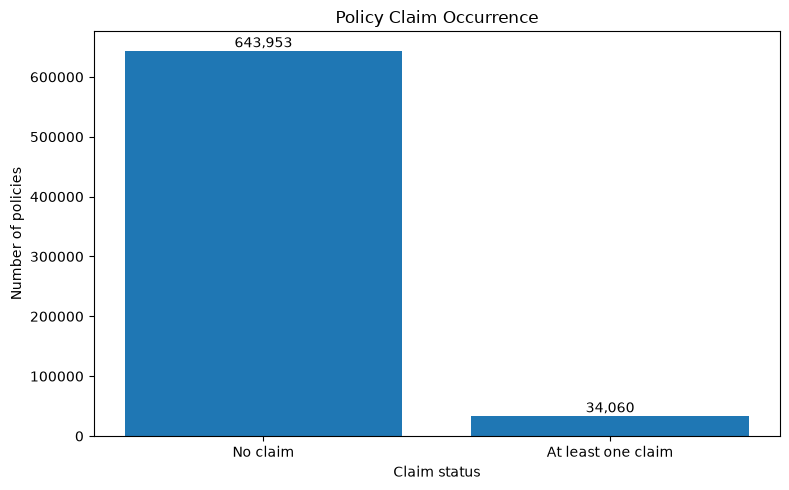

Saved figure to: c:\Users\Gabriel\Documents\Projects\insurance-risk-intelligence\reports\figures\eda\claim_occurrence.png


In [18]:
claim_occurrence_counts = (
    policy["HasClaim"]
    .value_counts()
    .reindex([0, 1], fill_value=0)
)

claim_occurrence_labels = [
    "No claim",
    "At least one claim",
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    claim_occurrence_labels,
    claim_occurrence_counts.values,
)

plt.title("Policy Claim Occurrence")
plt.xlabel("Claim status")
plt.ylabel("Number of policies")

for bar, value in zip(
    bars,
    claim_occurrence_counts.values,
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom",
    )

save_figure("claim_occurrence.png")

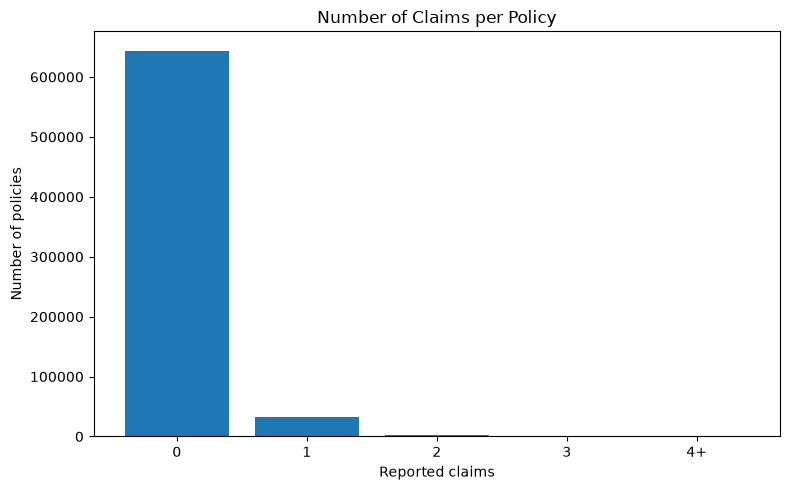

Saved figure to: c:\Users\Gabriel\Documents\Projects\insurance-risk-intelligence\reports\figures\eda\claim_count_distribution.png


In [19]:
claim_count_group = policy["ClaimNb"].where(
    policy["ClaimNb"] < 4,
    4,
)

claim_count_distribution = (
    claim_count_group
    .value_counts()
    .reindex([0, 1, 2, 3, 4], fill_value=0)
)

claim_count_labels = [
    "0",
    "1",
    "2",
    "3",
    "4+",
]

plt.figure(figsize=(8, 5))

plt.bar(
    claim_count_labels,
    claim_count_distribution.values,
)

plt.title("Number of Claims per Policy")
plt.xlabel("Reported claims")
plt.ylabel("Number of policies")

save_figure("claim_count_distribution.png")

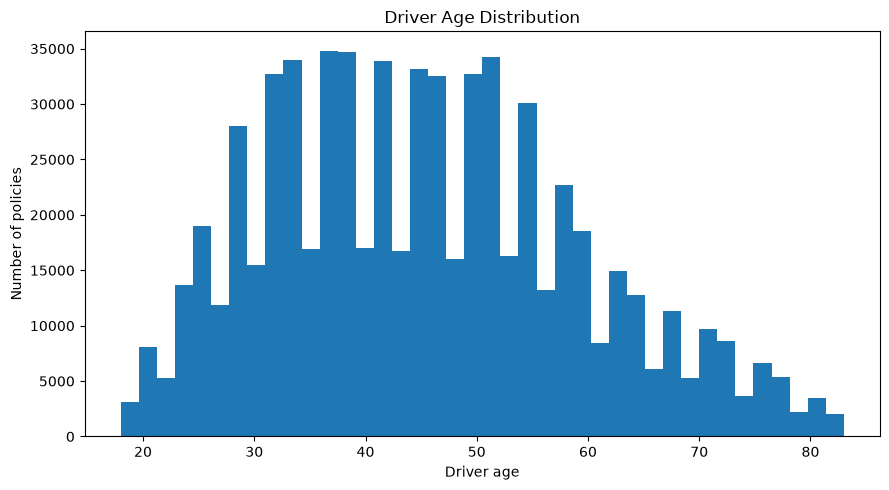

Saved figure to: c:\Users\Gabriel\Documents\Projects\insurance-risk-intelligence\reports\figures\eda\driver_age_distribution.png
Chart upper limit: 83.0


In [20]:
driver_age_upper = policy["DrivAge"].quantile(0.995)

driver_age_for_plot = policy.loc[
    policy["DrivAge"] <= driver_age_upper,
    "DrivAge",
]

plt.figure(figsize=(9, 5))

plt.hist(
    driver_age_for_plot,
    bins=40,
)

plt.title("Driver Age Distribution")
plt.xlabel("Driver age")
plt.ylabel("Number of policies")

save_figure("driver_age_distribution.png")

print(
    "Chart upper limit:",
    f"{driver_age_upper:.1f}",
)

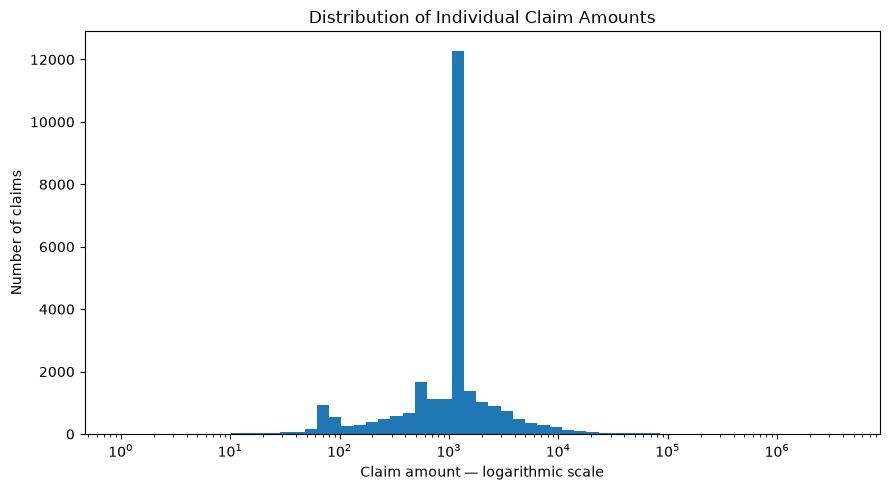

Saved figure to: c:\Users\Gabriel\Documents\Projects\insurance-risk-intelligence\reports\figures\eda\claim_amount_distribution_log.png


In [21]:
claim_amounts = valid_severity.loc[
    valid_severity["ClaimAmount"] > 0,
    "ClaimAmount",
]

log_bins = np.logspace(
    np.log10(claim_amounts.min()),
    np.log10(claim_amounts.max()),
    60,
)

plt.figure(figsize=(9, 5))

plt.hist(
    claim_amounts,
    bins=log_bins,
)

plt.xscale("log")

plt.title("Distribution of Individual Claim Amounts")
plt.xlabel("Claim amount — logarithmic scale")
plt.ylabel("Number of claims")

save_figure("claim_amount_distribution_log.png")

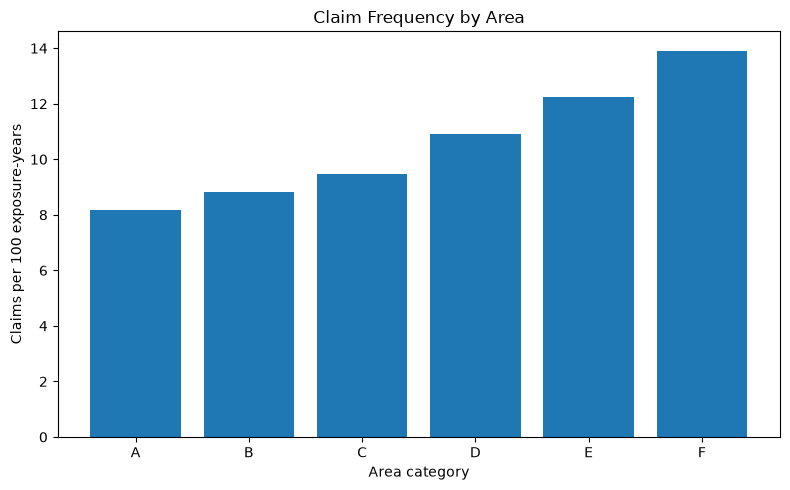

Saved figure to: c:\Users\Gabriel\Documents\Projects\insurance-risk-intelligence\reports\figures\eda\claim_frequency_by_area.png


In [22]:
area_plot = area_summary.copy()

plt.figure(figsize=(8, 5))

plt.bar(
    area_plot.index.astype(str),
    area_plot["ClaimsPer100ExposureYears"],
)

plt.title("Claim Frequency by Area")
plt.xlabel("Area category")
plt.ylabel("Claims per 100 exposure-years")

save_figure("claim_frequency_by_area.png")

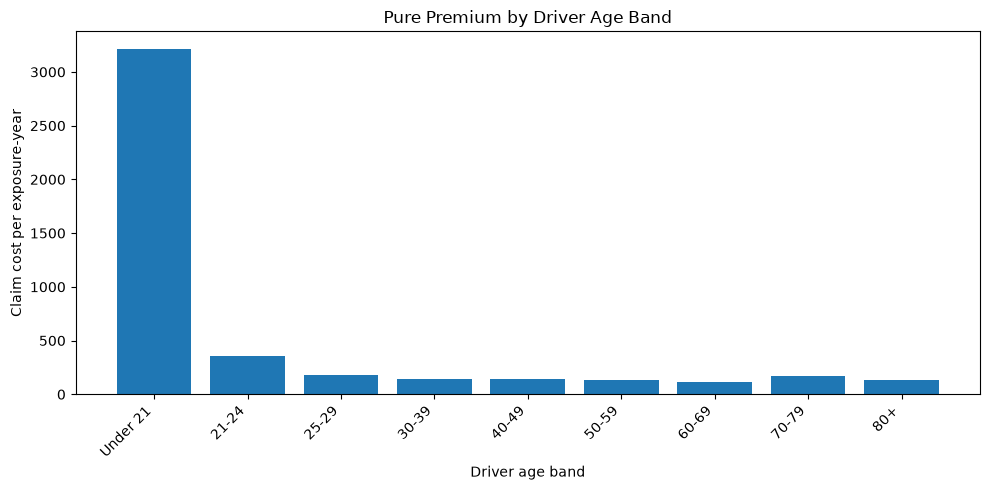

Saved figure to: c:\Users\Gabriel\Documents\Projects\insurance-risk-intelligence\reports\figures\eda\pure_premium_by_driver_age_band.png


In [23]:
driver_age_plot = driver_age_summary.dropna(
    subset=["PurePremium"]
)

plt.figure(figsize=(10, 5))

plt.bar(
    driver_age_plot.index.astype(str),
    driver_age_plot["PurePremium"],
)

plt.title("Pure Premium by Driver Age Band")
plt.xlabel("Driver age band")
plt.ylabel("Claim cost per exposure-year")
plt.xticks(rotation=45, ha="right")

save_figure("pure_premium_by_driver_age_band.png")

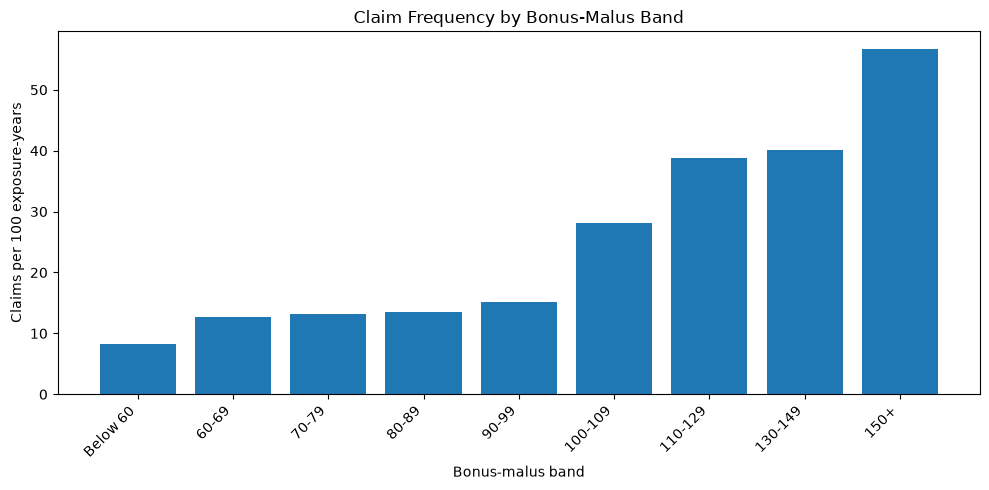

Saved figure to: c:\Users\Gabriel\Documents\Projects\insurance-risk-intelligence\reports\figures\eda\claim_frequency_by_bonus_malus_band.png


In [24]:
bonus_malus_plot = bonus_malus_summary.dropna(
    subset=["ClaimsPer100ExposureYears"]
)

plt.figure(figsize=(10, 5))

plt.bar(
    bonus_malus_plot.index.astype(str),
    bonus_malus_plot["ClaimsPer100ExposureYears"],
)

plt.title("Claim Frequency by Bonus-Malus Band")
plt.xlabel("Bonus-malus band")
plt.ylabel("Claims per 100 exposure-years")
plt.xticks(rotation=45, ha="right")

save_figure("claim_frequency_by_bonus_malus_band.png")

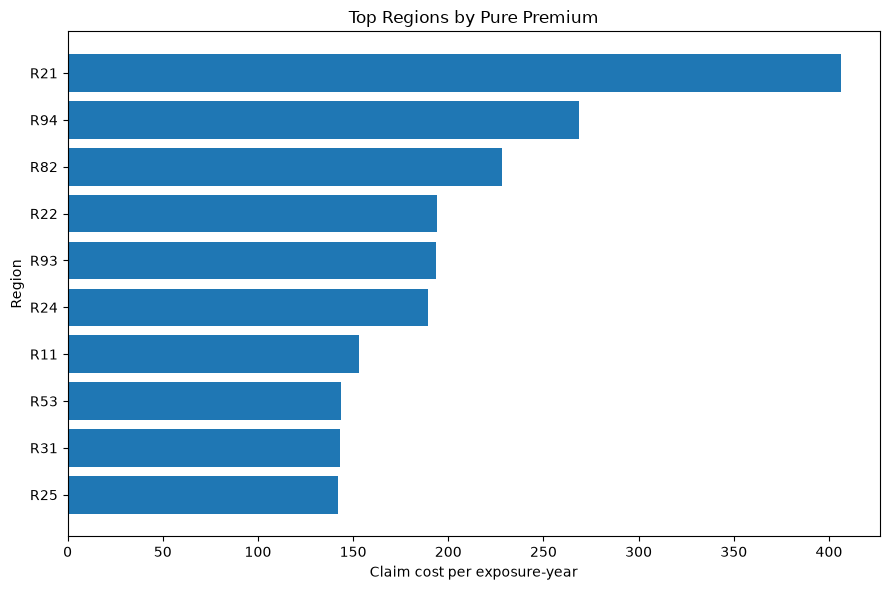

Saved figure to: c:\Users\Gabriel\Documents\Projects\insurance-risk-intelligence\reports\figures\eda\top_regions_by_pure_premium.png


In [25]:
region_plot = region_summary.loc[
    region_summary["CompleteLossExposure"] >= 1_000
].copy()

top_regions = (
    region_plot.nlargest(
        10,
        "PurePremium",
    )
    .sort_values(
        "PurePremium",
        ascending=True,
    )
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_regions.index.astype(str),
    top_regions["PurePremium"],
)

plt.title("Top Regions by Pure Premium")
plt.xlabel("Claim cost per exposure-year")
plt.ylabel("Region")

save_figure("top_regions_by_pure_premium.png")

## Frequency, Severity, and Pure Premium

Insurance risk has multiple dimensions.

- Frequency measures how often claims occur.
- Severity measures the average financial size of claims.
- Pure premium combines claim cost and exposure.

A segment can have high pure premium because it has frequent claims,
severe claims, or both.

In [26]:
comparison_columns = [
    "Policies",
    "Exposure",
    "ClaimsPer100ExposureYears",
    "AverageClaimSeverity",
    "PurePremium",
]

display(
    driver_age_summary[
        comparison_columns
    ]
)

,Policies,Exposure,ClaimsPer100ExposureYears,AverageClaimSeverity,PurePremium
DrivAgeBand,,,,,
Under 21,6816,"2,584.583",24.878,"13,431.196","3,216.906"
21-24,23382,"9,904.578",17.376,"2,479.363",352.415
25-29,58807,"25,785.261",11.243,"2,051.954",180.146
30-39,168564,"82,358.128",8.924,"1,978.029",138.430
40-49,165702,"87,685.666",10.311,"1,872.063",142.020
50-59,142600,"79,910.648",9.781,"1,864.322",133.035
60-69,67812,"40,089.862",9.284,"1,849.268",116.022
70-79,36225,"24,089.056",9.660,"2,883.057",174.653
80+,8105,"6,091.663",9.570,"2,077.939",133.482


In [27]:
def get_highest_segment(
    summary: pd.DataFrame,
    metric: str,
) -> tuple[str, float]:
    """Return the segment with the largest valid metric."""

    valid_values = summary[metric].dropna()

    segment = valid_values.idxmax()
    value = valid_values.max()

    return str(segment), float(value)


def get_lowest_segment(
    summary: pd.DataFrame,
    metric: str,
) -> tuple[str, float]:
    """Return the segment with the smallest valid metric."""

    valid_values = summary[metric].dropna()

    segment = valid_values.idxmin()
    value = valid_values.min()

    return str(segment), float(value)


highest_area_frequency = get_highest_segment(
    area_summary,
    "ClaimsPer100ExposureYears",
)

lowest_area_frequency = get_lowest_segment(
    area_summary,
    "ClaimsPer100ExposureYears",
)

highest_driver_pure_premium = get_highest_segment(
    driver_age_summary,
    "PurePremium",
)

highest_bonus_malus_frequency = get_highest_segment(
    bonus_malus_summary,
    "ClaimsPer100ExposureYears",
)

highest_region_pure_premium = get_highest_segment(
    region_plot,
    "PurePremium",
)

print(
    "Highest area claim frequency:",
    highest_area_frequency,
)

print(
    "Lowest area claim frequency:",
    lowest_area_frequency,
)

print(
    "Highest driver-age pure premium:",
    highest_driver_pure_premium,
)

print(
    "Highest bonus-malus claim frequency:",
    highest_bonus_malus_frequency,
)

print(
    "Highest eligible region pure premium:",
    highest_region_pure_premium,
)

Highest area claim frequency: ('F', 13.912749832913136)
Lowest area claim frequency: ('A', 8.17016434067984)
Highest driver-age pure premium: ('Under 21', 3216.905790829392)
Highest bonus-malus claim frequency: ('150+', 56.7655036689058)
Highest eligible region pure premium: ('R21', 406.5060568448357)


In [28]:
claim_amount_percentiles = (
    valid_severity["ClaimAmount"]
    .quantile(
        [
            0.00,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
            0.995,
            0.999,
            1.00,
        ]
    )
    .rename("ClaimAmount")
    .to_frame()
)

claim_amount_percentiles.index = [
    "Minimum",
    "25th percentile",
    "Median",
    "75th percentile",
    "90th percentile",
    "95th percentile",
    "99th percentile",
    "99.5th percentile",
    "99.9th percentile",
    "Maximum",
]

display(claim_amount_percentiles)

,ClaimAmount
Minimum,1.000
25th percentile,686.810
Median,"1,172.000"
75th percentile,"1,228.080"
90th percentile,"2,799.072"
95th percentile,"4,861.685"
99th percentile,"16,793.704"
99.5th percentile,"34,386.987"
99.9th percentile,"162,784.442"
Maximum,"4,075,400.560"


In [29]:
largest_complete_losses = (
    policy.loc[
        policy["PurePremiumModelEligible"]
        & policy["CompleteTotalClaimAmount"].gt(0),
        [
            "IDpol",
            "ClaimNb",
            "Exposure",
            "Area",
            "VehPower",
            "VehAge",
            "DrivAge",
            "BonusMalus",
            "VehBrand",
            "VehGas",
            "Region",
            "CompleteTotalClaimAmount",
            "CompletePurePremium",
        ],
    ]
    .nlargest(
        20,
        "CompleteTotalClaimAmount",
    )
)

display(largest_complete_losses)

,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Region,CompleteTotalClaimAmount,CompletePurePremium
150027,1120377,1,0.220,B,9,13,19,100,B2,'Regular',R24,"4,075,400.560","18,524,548.000"
54317,110846,2,0.430,C,6,13,20,100,B1,'Regular',R24,"1,404,185.520","3,265,547.721"
270621,2141337,1,0.320,D,4,14,18,100,B2,'Regular',R82,"1,301,172.600","4,066,164.375"
416629,3122016,1,0.910,E,7,7,40,63,B11,'Diesel',R82,"774,411.500","851,001.648"
203399,2008127,3,0.360,D,4,2,57,50,B4,'Regular',R82,"399,213.660","1,108,926.833"
368669,3025890,2,0.090,A,7,1,36,50,B12,'Diesel',R21,"382,955.140","4,255,057.111"
147894,1117644,1,0.850,C,7,1,21,90,B3,'Diesel',R53,"307,096.420","361,289.906"
75668,158309,1,0.750,A,6,3,46,50,B1,'Diesel',R24,"301,635.490","402,180.653"
396360,3075820,1,0.580,E,7,18,78,50,B10,'Regular',R93,"287,423.000","495,556.897"
431421,3150210,1,0.480,D,6,4,61,54,B3,'Diesel',R24,"281,897.490","587,286.438"


In [30]:
findings_document = f"""# Exploratory Data Analysis Findings

## Portfolio Overview

- Total policies: {total_policies:,}
- Total exposure-years: {total_exposure:,.2f}
- Total reported claims: {total_claims:,}
- Policies with at least one claim: {policies_with_claims:,}
- Claim occurrence rate: {claim_occurrence_rate:.2%}
- Claims per 100 exposure-years: {claims_per_100_exposure_years:.2f}
- Policies with complete claim-cost outcomes: {len(complete_loss_policies):,}
- Average complete claim severity: {average_claim_severity:,.2f}
- Complete pure premium: {pure_premium:,.2f}

## Claim Occurrence

Most policies did not have a reported claim during their exposure
period. The claim-occurrence outcome is therefore imbalanced.

Future classification models should not be evaluated using accuracy
alone. Recall, precision, PR-AUC, ROC-AUC and calibration will also be
considered.

## Claim Amount Distribution

Individual claim amounts are strongly right-skewed. Most claims are
relatively small compared with a limited number of very expensive
claims.

Large claims were retained because extreme insurance losses may be
legitimate. Modelling stages will examine suitable distributions and
transformations rather than deleting extreme observations
automatically.

## Area Analysis

- Highest observed area claim frequency:
  `{highest_area_frequency[0]}` with
  {highest_area_frequency[1]:.2f} claims per 100 exposure-years.
- Lowest observed area claim frequency:
  `{lowest_area_frequency[0]}` with
  {lowest_area_frequency[1]:.2f} claims per 100 exposure-years.

These are unadjusted comparisons. Area groups may differ in driver,
vehicle, exposure and geographic characteristics.

## Driver Age Analysis

The driver-age band with the highest observed pure premium was
`{highest_driver_pure_premium[0]}`, with an estimated complete claim
cost of {highest_driver_pure_premium[1]:,.2f} per exposure-year.

This is an unadjusted descriptive relationship and should not be
interpreted as a causal effect.

## Bonus-Malus Analysis

The bonus-malus band with the highest observed claim frequency was
`{highest_bonus_malus_frequency[0]}`, with
{highest_bonus_malus_frequency[1]:.2f} claims per 100 exposure-years.

The relationship will be examined further during statistical and
predictive modelling.

## Regional Analysis

Among regions with at least 1,000 complete exposure-years, the region
with the highest observed pure premium was
`{highest_region_pure_premium[0]}`, with a pure premium of
{highest_region_pure_premium[1]:,.2f}.

The minimum exposure rule was used to avoid emphasizing highly unstable
rates based on very small samples.

## Frequency, Severity and Pure Premium

The analysis distinguishes:

- claim occurrence: whether a policy had a claim;
- claim frequency: number of claims per exposure-year;
- claim severity: average claim cost;
- pure premium: total claim cost per exposure-year.

Segments with high claim frequency do not necessarily have the highest
average severity.

## Data Completeness Limitation

Claim frequency is available for all structurally valid policies, but
severity information is incomplete for some policies.

Pure-premium and severity summaries use model-eligibility indicators
created during data preparation. Results should therefore be
interpreted as estimates based on the complete analytical sample.

## Interpretation Limitations

The analysis is descriptive and does not establish causality.

Differences between groups may reflect confounding factors and
interactions among driver, vehicle and geographic characteristics.

The data represents a historical French insurance portfolio and should
not be presented as current Canadian insurance experience.
"""

EDA_FINDINGS_PATH.write_text(
    findings_document,
    encoding="utf-8",
)

print(f"Saved findings to: {EDA_FINDINGS_PATH}")

Saved findings to: c:\Users\Gabriel\Documents\Projects\insurance-risk-intelligence\docs\eda_findings.md
